# PFAS Detection in US Drinking Water: XGBoost + SHAP

Predicting whether a US public water system has detectable PFAS from its size, location, water source, and sampling year, and using SHAP to see what drives detection.

## 1. Data Preparation

In [1]:
# PFAS Detection in US Drinking Water: XGBoost + SHAP

#Download the data
# Pulls EPA's national UCMR5 PFAS monitoring dataset directly into Colab as a
# zip file, then extracts it. This avoids manually downloading a large file.
import urllib.request
import zipfile

url = "https://www.epa.gov/system/files/other-files/2023-08/ucmr5-occurrence-data.zip"
urllib.request.urlretrieve(url, "ucmr5.zip")
with zipfile.ZipFile("ucmr5.zip", "r") as z:
    z.extractall("ucmr5_data")
print("Downloaded and extracted.")

Downloaded and extracted.


In [2]:
#Load the data
# The file is tab-separated, not comma-separated, and contains the micro
# sign (µg/L) which requires 'latin-1' encoding instead of the default UTF-8.
import pandas as pd

filepath = "ucmr5_data/UCMR5_All.txt"
df = pd.read_csv(filepath, sep='\t', encoding='latin-1')
print("Shape:", df.shape)
df.head()

/tmp/ipykernel_632/75282925.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, sep='\t', encoding='latin-1')


Shape: (1928117, 24)


,PWSID,PWSName,Size,FacilityID,FacilityName,FacilityWaterType,SamplePointID,SamplePointName,SamplePointType,AssociatedFacilityID,...,MRL,Units,MethodID,AnalyticalResultsSign,AnalyticalResultValue,SampleEventCode,MonitoringRequirement,Region,State,UCMR1SampleType
0,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,NaN,...,0.005,µg/L,EPA 533,<,NaN,SE1,AM,1,01,NaN
1,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,NaN,...,0.003,µg/L,EPA 533,=,0.0035,SE1,AM,1,01,NaN
2,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,NaN,...,0.003,µg/L,EPA 533,<,NaN,SE1,AM,1,01,NaN
3,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,NaN,...,0.004,µg/L,EPA 533,<,NaN,SE1,AM,1,01,NaN
4,010106001,Mashantucket Pequot Water System,L,00006,MPTN WTP,GU,TP1,Entry point to Dist. System,EP,NaN,...,0.004,µg/L,EPA 533,<,NaN,SE1,AM,1,01,NaN


In [3]:
#Mark detect / non-detect
# AnalyticalResultsSign is '=' when a PFAS was actually measured (a detect)
# and '<' when the result was below the detection threshold (a non-detect).
# This converts that into a clean 0/1 column for every measurement row.
df['Detect'] = (df['AnalyticalResultsSign'] == '=').astype(int)
print(df['Detect'].value_counts())
print("Percent of measurements detected:", round(df['Detect'].mean()*100, 2), "%")

Detect
0    1872227
1      55890
Name: count, dtype: int64
Percent of measurements detected: 2.9 %


In [4]:
#One verdict per water system
# Each water system has many measurement rows (multiple PFAS chemicals,
# multiple samples). A system counts as PFAS-detected if ANY of its rows
# was a detect. Taking the max of a 0/1 column achieves exactly this: the
# result is 1 if at least one row was a 1, and 0 only if every row was 0.
system_detect = df.groupby('PWSID')['Detect'].max()
print("Unique systems:", len(system_detect))
print("Percent of systems with PFAS:", round(system_detect.mean()*100, 2), "%")

Unique systems: 10299
Percent of systems with PFAS: 59.72 %


In [5]:
#Build the per-system table
# Collapses the 1.9 million measurement rows down to one row per water
# system, keeping each system's size, state, region, and water source type
# (these are constant per system, so 'first' just grabs the one value),
# plus the detect/non-detect verdict computed above.
system_info = df.groupby('PWSID').agg({
    'Size': 'first',
    'State': 'first',
    'Region': 'first',
    'FacilityWaterType': 'first'
})
system_info['Detected'] = system_detect
print("Shape:", system_info.shape)
system_info.head()


Shape: (10299, 5)


,Size,State,Region,FacilityWaterType,Detected
PWSID,,,,,
010106001,L,01,1,GU,1
010109005,L,01,1,SW,0
020000005,S,02,2,SW,0
020000008,S,02,2,GW,0
040000002,S,04,4,GW,0


In [6]:
#Check every categorical column for junk values
# Before modeling, inspect every category in every column. This is what
# surfaces the State column's hidden problem: alongside real two-letter
# state codes, it also contains numeric tribal/region codes and US
# territory codes, neither of which belong in a state-level analysis.
for col in ['Size', 'State', 'Region', 'FacilityWaterType']:
    print(col, "->", sorted(system_info[col].astype(str).unique()))
    print()
print("Missing values:")
print(system_info.isnull().sum())

Size -> ['L', 'S']

State -> ['01', '02', '04', '05', '06', '07', '08', '09', '10', 'AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MP', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NN', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']

Region -> ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']

FacilityWaterType -> ['GU', 'GW', 'MX', 'SW']

Missing values:
Size                 0
State                0
Region               0
FacilityWaterType    0
Detected             0
dtype: int64


In [7]:
#Clean to valid US states (50 + DC)
# The State column contains a mix of real two-letter state codes, numeric
# region/tribal codes (e.g. '01'), and US territory codes (e.g. 'PR', 'GU').
# We keep only the 50 states plus DC, since the analysis and the later
# choropleth map are both state-level. valid_states is the standard list
# of USPS state abbreviations.
valid_states = ['AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL','GA','HI','ID','IL',
                'IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT',
                'NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI',
                'SC','SD','TN','TX','UT','VT','VA','WA','WV','WI','WY']

# Verify the list against the data itself before trusting it: print exactly
# which State values will be excluded, so it can be confirmed by eye that
# only junk codes and territories are being dropped, not real states.
all_states_in_data = sorted(system_info['State'].astype(str).unique())
excluded = [s for s in all_states_in_data if s not in valid_states]
print("Values that will be excluded as non-US-states:", excluded)

before = len(system_info)
system_info = system_info[system_info['State'].isin(valid_states)]
print("Rows removed:", before - len(system_info))
print("Rows remaining:", len(system_info))

Values that will be excluded as non-US-states: ['01', '02', '04', '05', '06', '07', '08', '09', '10', 'AS', 'GU', 'MP', 'NN', 'PR', 'VI']
Rows removed: 225
Rows remaining: 10074


In [8]:
#Add sampling year as a feature
# CollectionDate is a text date string; converting it to a real date type
# lets us pull out just the year. A system may be sampled more than once
# across 2023-2025, so we take its most common (mode) sampling year as a
# single representative value per system.
df['CollectionDate'] = pd.to_datetime(df['CollectionDate'], errors='coerce')
df['Year'] = df['CollectionDate'].dt.year

system_year = df.groupby('PWSID')['Year'].agg(lambda x: x.mode()[0])
system_info['Year'] = system_year
print(system_info[['Year']].head())
print(system_info['Year'].value_counts())

           Year
PWSID          
AK2110342  2025
AK2110601  2025
AK2120232  2025
AK2130075  2025
AK2210605  2024
Year
2024    3889
2023    3545
2025    2640
Name: count, dtype: int64


## 2. Feature Encoding and Train / Test Split

In [9]:
#Encode predictors
# XGBoost needs numbers, not text categories. One-hot encoding turns each
# category into its own True/False column (e.g. State_TX, State_CA, ...),
# so the model can use them without assuming a fake numeric order between
# categories that have none.
features = system_info[['Size', 'State', 'FacilityWaterType', 'Year']]
target = system_info['Detected']

features_encoded = pd.get_dummies(features, columns=['Size', 'State', 'FacilityWaterType', 'Year'])
print("Encoded shape:", features_encoded.shape)

Encoded shape: (10074, 60)


In [10]:
#Train/test split
# 80% of systems train the model; the remaining 20% are held back, unseen,
# to honestly measure how well the model generalizes. stratify=target keeps
# the same detect/non-detect ratio in both the train and test sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target,
    test_size=0.2, random_state=42, stratify=target
)
print("Training systems:", X_train.shape[0])
print("Test systems:", X_test.shape[0])

Training systems: 8059
Test systems: 2015


## 3. Model Training and Cross-Validation

In [11]:
#Install and train XGBoost
# XGBoost builds many decision trees in sequence, each one correcting the
# previous trees' mistakes. It's the standard choice for tabular data like
# this because it captures non-linear relationships and feature
# interactions that a simpler linear model would miss.
# !pip install xgboost
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

# Create a shuffled cross-validator
cv_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = XGBClassifier(random_state=42, eval_metric= 'logloss')

# Pass the shuffled CV strategy here
scores = cross_val_score(cv_model, features_encoded, target, cv=cv_shuffle, scoring='f1_macro')
print("CV macro-F1 per fold:", scores.round(3))
print("Mean:", scores.mean().round(3), "+/-", scores.std().round(3))

# Do the same for the baseline
dummy = DummyClassifier(strategy='most_frequent')
base = cross_val_score(dummy, features_encoded, target, cv=cv_shuffle, scoring='f1_macro')
print("Baseline (always-PFAS) macro-F1:", base.mean().round(3))

CV macro-F1 per fold: [0.662 0.676 0.678 0.694 0.673]
Mean: 0.677 +/- 0.01
Baseline (always-PFAS) macro-F1: 0.374


## 4. Evaluation and Model Comparison

In [13]:
#Evaluate
# Tests the trained model on the 20% of systems it has never seen. Accuracy
# alone can be misleading, so the full classification report also reports
# precision and recall separately for each class.
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred,
        target_names=['No PFAS (0)', 'PFAS detected (1)']))

Accuracy: 0.705
                   precision    recall  f1-score   support

      No PFAS (0)       0.67      0.53      0.59       809
PFAS detected (1)       0.72      0.82      0.77      1206

         accuracy                           0.71      2015
        macro avg       0.69      0.68      0.68      2015
     weighted avg       0.70      0.71      0.70      2015



In [14]:
# Baseline comparison: Dummy vs Logistic Regression vs XGBoost.
# Every number is computed here, not copied, so the table is honest.
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
}

rows = []
for name, clf in models.items():
    cvf1 = cross_val_score(clf, features_encoded, target, cv=cv, scoring="f1_macro").mean()
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    rows.append({
        "Model": name,
        "CV macro-F1": round(cvf1, 3),
        "Test accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision (PFAS)": round(precision_score(y_test, pred, pos_label=1, zero_division=0), 3),
        "Recall (PFAS)": round(recall_score(y_test, pred, pos_label=1, zero_division=0), 3),
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))

              Model  CV macro-F1  Test accuracy  Precision (PFAS)  Recall (PFAS)
   Baseline (Dummy)        0.374          0.599             0.599          1.000
Logistic Regression        0.665          0.688             0.725          0.772
            XGBoost        0.677          0.705             0.724          0.820


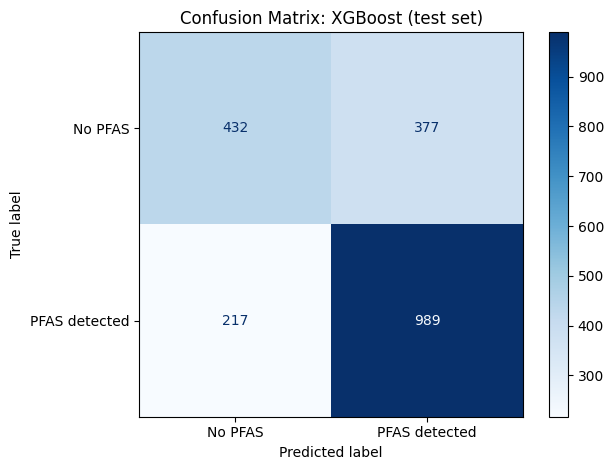

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No PFAS", "PFAS detected"]).plot(cmap="Blues")
plt.title("Confusion Matrix: XGBoost (test set)")
plt.tight_layout()
plt.show()

## 5. Model Interpretation with SHAP

In [16]:
# ===== Cell 13: Install and compute SHAP =====
# SHAP explains the trained model's predictions: for every system and every
# feature, it computes how much that feature pushed the prediction toward
# or away from "PFAS detected." TreeExplainer is the SHAP variant built
# specifically for tree-based models like XGBoost.
!pip install shap
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("SHAP shape:", shap_values.shape)

SHAP shape: (2015, 60)


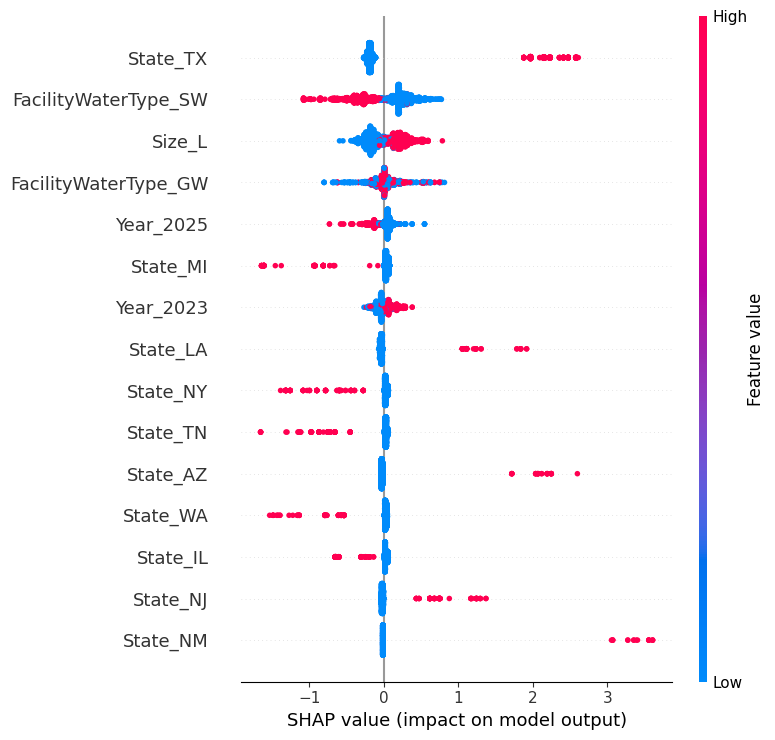

In [18]:
#SHAP feature importance plot
# Ranks all features by how much they influence the model's predictions
# on average, across all test systems. Longer bars mean more influence.
shap.summary_plot(shap_values, X_test, max_display=15)

## 6. Descriptive Analysis: Drivers and Chemicals

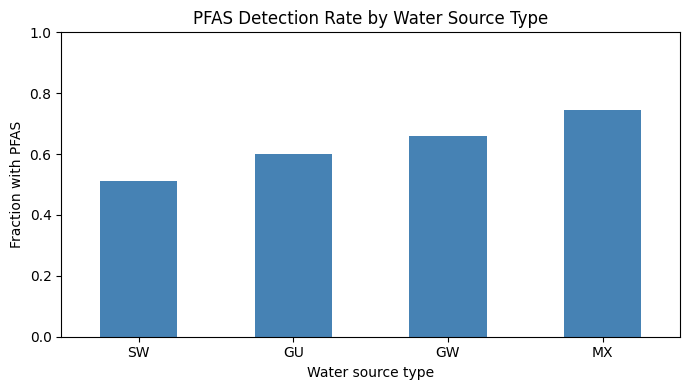

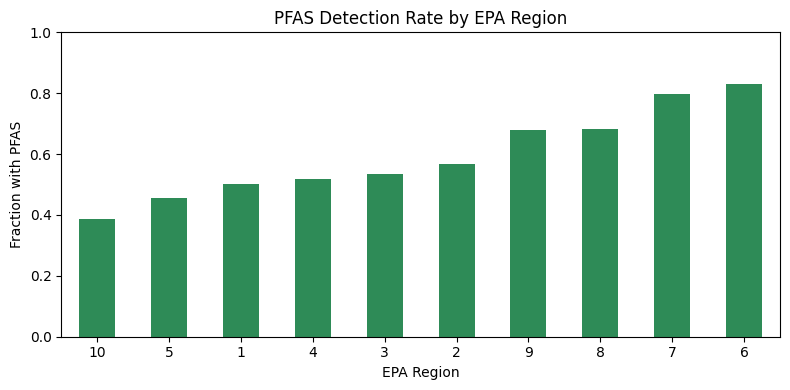

In [19]:
#PFAS rate by water type and region (raw verification)
# These bypass the model entirely and compute the actual PFAS detection
# rate directly from the data, grouped by water source type and by region.
# They exist to confirm, in plain numbers, that the SHAP findings reflect
# something real in the raw data rather than an artifact of the model.
import matplotlib.pyplot as plt

water_rates = system_info.groupby('FacilityWaterType')['Detected'].mean().sort_values()
plt.figure(figsize=(7,4))
water_rates.plot(kind='bar', color='steelblue')
plt.ylabel('Fraction with PFAS'); plt.xlabel('Water source type')
plt.title('PFAS Detection Rate by Water Source Type')
plt.xticks(rotation=0); plt.ylim(0,1); plt.tight_layout(); plt.show()

region_rates = system_info.groupby('Region')['Detected'].mean().sort_values()
plt.figure(figsize=(8,4))
region_rates.plot(kind='bar', color='seagreen')
plt.ylabel('Fraction with PFAS'); plt.xlabel('EPA Region')
plt.title('PFAS Detection Rate by EPA Region')
plt.xticks(rotation=0); plt.ylim(0,1); plt.tight_layout(); plt.show()

In [20]:
#PFAS rate by state map
# Same raw detection rate as above, now computed per state and drawn as a
# US choropleth map. state_names maps two-letter codes to full names so
# hovering over the interactive map shows readable labels.
import plotly.express as px

state_names = {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','DC':'District of Columbia',
    'FL':'Florida','GA':'Georgia','HI':'Hawaii','ID':'Idaho','IL':'Illinois',
    'IN':'Indiana','IA':'Iowa','KS':'Kansas','KY':'Kentucky','LA':'Louisiana',
    'ME':'Maine','MD':'Maryland','MA':'Massachusetts','MI':'Michigan','MN':'Minnesota',
    'MS':'Mississippi','MO':'Missouri','MT':'Montana','NE':'Nebraska','NV':'Nevada',
    'NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico','NY':'New York',
    'NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma','OR':'Oregon',
    'PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina','SD':'South Dakota',
    'TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont','VA':'Virginia',
    'WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming'
}
state_rates = system_info.groupby('State')['Detected'].mean().reset_index()
state_rates.columns = ['State', 'PFAS_rate']
state_rates['StateName'] = state_rates['State'].map(state_names)

fig = px.choropleth(state_rates, locations='State', locationmode='USA-states',
                    color='PFAS_rate', scope='usa', color_continuous_scale='Reds',
                    hover_name='StateName', labels={'PFAS_rate':'PFAS rate'},
                    title='PFAS Detection Rate by US State')
fig.show()

In [21]:
#Which PFAS chemicals dominate nationally
# UCMR5 tests for 29 PFAS chemicals plus lithium, a non-PFAS metal included
# in the same monitoring program. Lithium is explicitly excluded here so
# the "top PFAS" ranking is not contaminated by a non-PFAS substance.
detected_only = df[df['Detect'] == 1]
pfas_detected = detected_only[detected_only['Contaminant'] != 'lithium']

top_pfas = pfas_detected['Contaminant'].value_counts().head(10)
print("Top 10 most frequently detected PFAS (lithium excluded):")
print(top_pfas)

Top 10 most frequently detected PFAS (lithium excluded):
Contaminant
PFPeA      6832
PFHxA      5899
PFBS       5524
PFBA       5256
PFOS       4378
PFOA       4270
PFHxS      3170
PFHpA      1493
6:2 FTS     252
PFNA        173
Name: count, dtype: int64


In [22]:
#Which PFAS dominates by region
# For each EPA region, finds the single most frequently detected PFAS
# chemical there. "Most frequently detected" reflects how often a chemical
# was reported, not its concentration or health risk.
region_pfas = pfas_detected.groupby('Region')['Contaminant'].agg(lambda x: x.value_counts().idxmax())
print("Most frequently detected PFAS, by region:")
print(region_pfas)

Most frequently detected PFAS, by region:
Region
1      PFOA
2      PFOA
3     PFPeA
4      PFBS
5      PFBA
6      PFBA
7      PFBA
8     PFPeA
9     PFHxS
10     PFBS
Name: Contaminant, dtype: object
